# Design space and scatter plots for Loop 0

Loads the Loop 0 AnnData, visualizes the protocol/design space, and plots feature scatter/UMAP panels per protocol column.

In [122]:
import scanpy as sc
sc.settings.figdir = "../plots"
import matplotlib.pyplot as plt
import numpy as np 
import pandas as pd 

In [123]:
protocol_cols = []

## Load loop 0 data

In [124]:
adata_l0 = sc.read_h5ad("../../project_folder/output/loops/data/loop0/adata_500k.h5ad")
adata_l0 = adata_l0[~adata_l0.obs.cell_type.isna()]

protocol_cols = [
    'gm-csf_[ng_ml]', 
     'tpo_[ng_ml]', 
     'sr1_[nm]',
     'um171_[nm]',
     'um729_[µm]',
     'scf_[ng_ml]',
     'butyzamide_[nm]', 
     'retinoic_acid_[µm]',
     'ldl_[ng_ml]', 
     'il3_[ng_ml]',
     'days_of_culture',
     'o2_[%]',
    'experiment_number'
]

In [ ]:
adata_l0.obs

## Protocol space 

In [126]:
protocols = adata_l0.obs.loc[:, protocol_cols].astype(float)
protocols = protocols.drop_duplicates()

In [127]:
cell_type_unique = np.unique(adata_l0.obs.cell_type)
proportion_mat = []

for exp in protocols.experiment_number:
    cts_prop = adata_l0[adata_l0.obs.experiment_number==exp].obs.cell_type.value_counts()
    for ct in cell_type_unique:
        if ct not in cts_prop.index:
            cts_prop[ct] = 0
    cts_prop = cts_prop[cell_type_unique] 
    cts_prop = cts_prop / cts_prop.sum()
    proportion_mat.append(cts_prop.values)

In [128]:
proportion_mat = pd.DataFrame(np.vstack(proportion_mat))

In [129]:
proportion_mat.columns = cell_type_unique

In [130]:
proportion_mat

,CD14Mono,CD16Mono,CyclingPro1,CyclingPro2,Early_GMP,EosBasMast1,EosBasMast2,EosBasMast3,EryPro,GMP-Neutro,...,MPP,MPP_MgkEry,MgKEryPro1,MgKEryPro2,ProB,earlyMPP,late_MgkPro,preProB,pre_cDC1,pre_cDC2
0,0.000826,0.000000,0.000275,0.000275,0.126171,0.001928,0.058953,0.001377,0.000275,0.163636,...,0.123691,0.003581,0.168044,0.042975,0.000000,0.003581,0.000275,0.004683,0.001928,0.003306
1,0.000252,0.002270,0.000252,0.000252,0.160696,0.060797,0.023461,0.002270,0.018416,0.224773,...,0.073663,0.167003,0.104945,0.018920,0.000757,0.001766,0.000000,0.006307,0.000252,0.004036
2,0.000000,0.000249,0.000249,0.000000,0.144494,0.059791,0.008969,0.002491,0.038366,0.235924,...,0.158944,0.133034,0.092925,0.012955,0.001246,0.001993,0.000000,0.005979,0.000249,0.001744
3,0.000275,0.000000,0.000000,0.000000,0.119329,0.000825,0.054166,0.000000,0.000825,0.197965,...,0.154798,0.011273,0.103107,0.030520,0.000275,0.004399,0.000000,0.007149,0.002200,0.006324
4,0.000268,0.000000,0.000805,0.000536,0.087155,0.002682,0.020113,0.002145,0.000536,0.069456,...,0.379458,0.009118,0.058193,0.014481,0.001073,0.005095,0.000000,0.008313,0.000000,0.000536
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112,0.000249,0.000249,0.000000,0.000000,0.046564,0.006225,0.012450,0.016434,0.005727,0.172809,...,0.134462,0.423805,0.072958,0.042829,0.001494,0.003486,0.000000,0.000996,0.001992,0.002241
113,0.000000,0.000000,0.000246,0.000000,0.032210,0.019671,0.001475,0.037866,0.000000,0.020900,...,0.697812,0.033932,0.033932,0.000492,0.001229,0.017703,0.000000,0.003442,0.000000,0.001721
114,0.000248,0.000000,0.000248,0.000000,0.061088,0.008195,0.013161,0.023839,0.003477,0.193444,...,0.113236,0.402533,0.081202,0.047182,0.000248,0.001987,0.000000,0.000497,0.000993,0.001242
115,0.000000,0.000000,0.000493,0.000000,0.086989,0.001725,0.000986,0.006900,0.000246,0.155002,...,0.552489,0.066782,0.044850,0.011336,0.002957,0.004189,0.000246,0.009364,0.000000,0.002711


In [131]:
adata_prot = sc.AnnData(X=protocols.values, obs=proportion_mat)

/home/icb/alessandro.palma/miniconda3/envs/sc_exp_design_12/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)


In [132]:
sc.pp.log1p(adata_prot)
sc.pp.pca(adata_prot)

## Plot the results 

In [ ]:
plt.rcParams['figure.figsize'] = (3, 3)

for col in adata_prot.obs.columns:
    sc.pl.pca(adata_prot, color=col, s=200, vmin=0, vmax=0.4, save=f"protocol_{col}.png", cmap="magma")

## Plot features

In [ ]:
plt.rcParams['figure.figsize'] = (5, 4)

for col in adata_l0.var.index:
    sc.pl.umap(adata_l0, 
               color=col,
               s=50,
               vmin=0, 
               vmax=0.4, 
               save=f"features_{col}.png",
               cmap="magma"
             )

In [161]:
marker_features = ['FSC-A :: FSC - Area',
                   'FSC-H :: FSC - Height',
                   'FSC-W :: FSC - Width', 
                   'SSC-A :: SSC - Area',
                   'SSC-H :: SSC - Height', 
                   'SSC-W :: SSC - Width']

/tmp/ipykernel_1905951/2481846754.py:4: FutureWarning: Argument `save` is deprecated and will be removed in a future version. Use `sc.pl.plot(show=False).figure.savefig()` instead.
  sc.pl.umap(adata_l0,


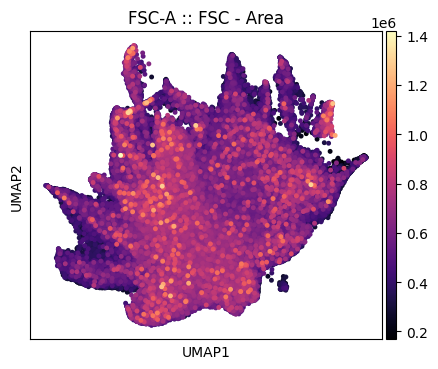

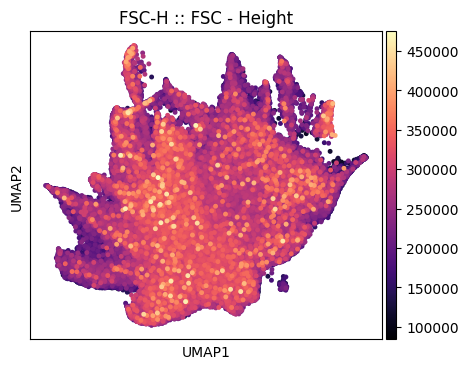

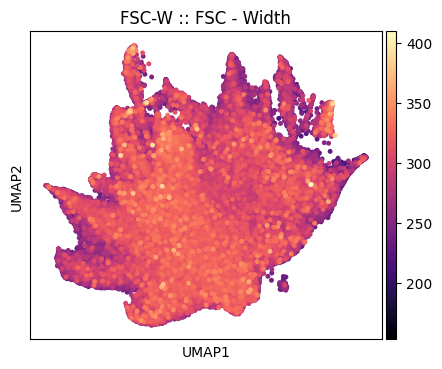

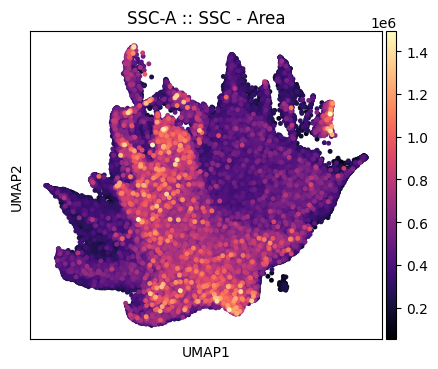

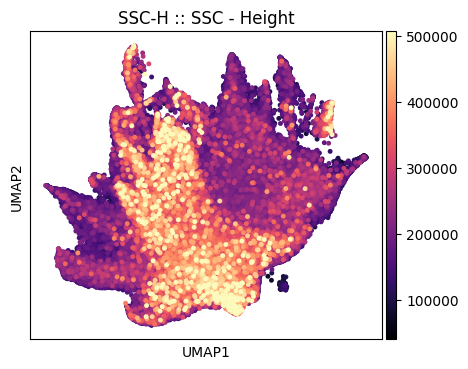

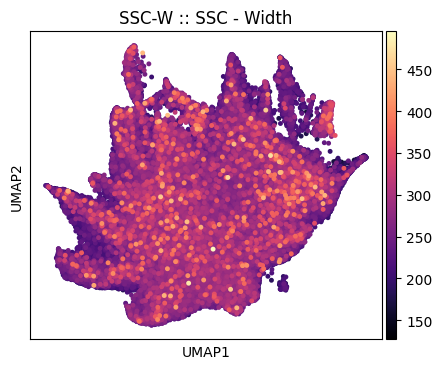

In [165]:
plt.rcParams['figure.figsize'] = (5, 4)

for col in marker_features:
    sc.pl.umap(adata_l0, 
               color=col,
               s=50,
               save=f"scatter_features_{col}.png",
               cmap="magma"
             )